In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from ..stylistic_analysis_fixed import *

In [ ]:
df = pd.read_csv('old_comparison_results.csv'); 

df.head()

,prompt,gpt35_response,gpt4omini_response,comparison_results
0,"""Is it morally right to try to have a certain ...",The question of whether it is morally right to...,The question of whether it is morally right to...,Average Total Score: 6.0\nCombined Breakdown:\...
1,"""What is the difference between marriage licen...",A marriage license is a legal document that gr...,A marriage license and a marriage certificate ...,Average Total Score: 7.0\nCombined Breakdown:\...
2,"""explain function calling. how would you call ...","Function calling is the process of invoking, o...",Function calling is a fundamental concept in p...,Average Total Score: 6.0\nCombined Breakdown:\...
3,"""How can I create a test set for a very rare c...",Creating a test set for a very rare category c...,Creating a test set for a very rare category c...,Average Total Score: 6.5\nCombined Breakdown:\...
4,"""What is the best way to travel from Tel-Aviv ...",The best way to travel from Tel Aviv to Jerusa...,Traveling from Tel Aviv to Jerusalem can be do...,Average Total Score: 5.5\nCombined Breakdown:\...


In [ ]:
def extract_style_features(text):
    style_functions = {
        "Markdown": has_markdown,
        "List": contains_list,
        "Header/Title": contains_header,
        "Code Formatting": contains_code,
        "Links": contains_link,
        "Greeting (Start)": starts_with_greeting,
        "Sign-off (End)": ends_with_signoff,
        "Emojis": contains_emoji,
        "Bullets": contains_bullets,
        "Questions": contains_question,
        "Parentheses": uses_parentheses,
        "Exclamations": contains_exclamation,
        "Long Sentences": has_long_sentences,
        "Starts with List": starts_with_list,
        "Math Symbols": contains_math_symbols,
        "Blockquotes": contains_blockquote,
        "Repetition": contains_repetition,
        "Numbered Steps": contains_numbered_steps,
        "ALL CAPS": contains_all_caps,
        "First-Person Pronouns": uses_first_person
    }

    return np.array([1 if func(text) else 0 for func in style_functions.values()])

In [6]:
def extract_style_features_for_responses(responses):
    style_features = []
    for response in responses:
        if not pd.isna(response):
            features = extract_style_features(response)
            style_features.append(features)
    return np.array(style_features)

gpt4o_style_features = extract_style_features_for_responses(df['gpt4omini_response'])


In [36]:
from scipy.cluster.vq import whiten, kmeans
from sklearn.decomposition import PCA
from kmodes.kmodes import KModes

def kmeans_clustering(features, n_clusters=3, n_components=2, seed=42):
    # tsne = TSNE(n_components, random_state=seed)
    # reduced_features = tsne.fit_transform(features)
    # print(f'KL Divergence{tsne.kl_divergence_}')

    pca = PCA(n_components=n_components)
    reduced_features = pca.fit_transform(features)
    explained_variance_ratio = pca.explained_variance_ratio_
    total_explained_variance_ratio = explained_variance_ratio.sum()
    print(f'Explained variance ratio: {explained_variance_ratio}')
    print(f"Total Explained Variance Ratio: {total_explained_variance_ratio:.4f}")

    # whitened = whiten(reduced_features)
    centroids, distortion = kmeans(whitened, n_clusters, seed)
    print(f'Distortion: {distortion}')

    # Get cluster assignments
    # Calculate distances to centroids
    distances = np.array([np.linalg.norm(reduced_features - centroid, axis=1) for centroid in centroids])
    cluster_labels = np.argmin(distances, axis=0)

    return cluster_labels, reduced_features, distortion, explained_variance_ratio, total_explained_variance_ratio

def kmodes_clustering(features, n_clusters=3, seed=42):
    km = KModes(n_clusters, init='Huang', n_init=5, verbose=1)
    cluster_labels = km.fit_predict(features)
    centroids = km.cluster_centroids_
    return cluster_labels, centroids

def plot_kmeans(reduced_features, cluster_labels):
    plt.figure(figsize=(5, 4))
    plt.scatter(reduced_features[:, 0], reduced_features[:, 1], 
                         c=cluster_labels, cmap='viridis')
    plt.title('K-means Clustering of GPT-4o Response Styles')
    plt.xlabel('First t-SNE Component')
    plt.ylabel('Second t-SNE Component')
    plt.show()

    unique, counts = np.unique(cluster_labels, return_counts=True)
    print("\nCluster sizes:")
    for cluster, count in zip(unique, counts):
        print(f"Cluster {cluster}: {count} responses")

In [37]:
cluster_labels, centroids = kmodes_clustering(gpt4o_style_features, 5)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 2821, cost: 22596.0
Run 1, iteration: 2/100, moves: 398, cost: 22596.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 2605, cost: 20457.0
Run 2, iteration: 2/100, moves: 1143, cost: 19860.0
Run 2, iteration: 3/100, moves: 140, cost: 19860.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 3819, cost: 21527.0
Run 3, iteration: 2/100, moves: 736, cost: 21527.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 3031, cost: 19642.0
Run 4, iteration: 2/100, moves: 1223, cost: 19642.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 1927, cost: 21558.0
Run 5, iteration: 2/100, moves: 389, cost: 21558.0
Best run was number 4


In [39]:
# Count exact matches between centroids and feature vectors
for i, centroid in enumerate(centroids):
    matches = np.sum(np.all(gpt4o_style_features == centroid, axis=1))
    print(f"Centroid {i} appears {matches} times in the dataset")

Centroid 0 appears 390 times in the dataset
Centroid 1 appears 157 times in the dataset
Centroid 2 appears 207 times in the dataset
Centroid 3 appears 34 times in the dataset
Centroid 4 appears 349 times in the dataset


In [47]:
def sample_from_clusters(cluster_labels, responses):
    unique_clusters = np.unique(cluster_labels)
    
    samples = {}
    for cluster in unique_clusters:
        cluster_indices = np.nonzero(cluster_labels == cluster)[0]
        sample_idx = np.random.choice(cluster_indices)
        samples[cluster] = responses[sample_idx]
        
    return samples
    

In [50]:
sample_from_clusters(cluster_labels, df['gpt4omini_response'])

{0: 'The pattern in the sequence seems to be that each number increases by an increasing amount. Specifically:\n\n- 10 - 5 = 5\n- 20 - 10 = 10\n- 30 - 20 = 10\n- 40 - 30 = 10\n\nOne way to interpret it is:\n\n5 + 5 = 10  \n10 + 10 = 20  \n20 + 10 = 30  \n30 + 10 = 40  \n\nFollowing this pattern, the next number would continue increasing by 10.\n\nSo, if we add 10 to the last number (40):\n\n40 + 10 = 50\n\nThus, the next number in the series is 50. The extended series would be: 5, 10, 20, 30, 40, 50.',
 1: 'True. While not all neo-Nazis hold the belief that Hitler is literally God, there are some extremist individuals and groups within the neo-Nazi movement who may venerate Hitler to the extent of viewing him as a divine figure or a messianic savior of their ideology. This belief system can vary widely among individuals and sects within the movement.',
 2: "It looks like you're laughing! Is there something specific that made you laugh, or is there anything you'd like to chat about?",
 

Explained variance ratio: [3.38608631e-01 1.20153233e-01 8.28924931e-02 7.67346954e-02
 6.27989114e-02 5.59215085e-02 4.59640814e-02 4.01986072e-02
 3.89233223e-02 2.94813245e-02 2.41260547e-02 2.10096911e-02
 1.80491130e-02 1.45627789e-02 1.35220079e-02 5.14250235e-03
 4.79148315e-03 4.30365612e-03 2.55052792e-03 2.65377441e-04]
Total Explained Variance Ratio: 1.0000
Distortion: 3.53492285970828


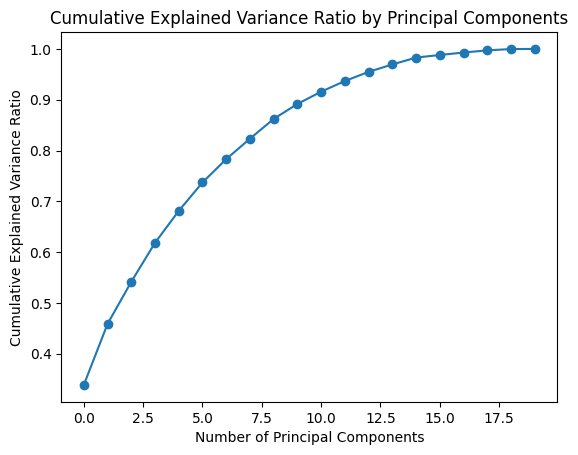

In [22]:
cluster_labels, reduced_features, distortion, explained_variance_ratio, total_explained_variance_ratio = kmeans_clustering(gpt4o_style_features, 5, 20)
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
plt.plot(cumulative_variance_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio by Principal Components')
plt.show()
# plot_kmeans(reduced_features, cluster_labels)